# EDA — Fruit and Vegetable Disease (Healthy vs Rotten)

EDA notebook for classifying **Healthy vs Rotten** across 14 fruit/vegetable types (28 classes).

**Dataset:** [Fruit and Vegetable Disease (Healthy vs Rotten)](https://www.kaggle.com/datasets/muhammad0subhan/fruit-and-vegetable-disease-healthy-vs-rotten) — Kaggle, ~29k images, 28 class folders (14 types × 2 states).

**Goals:**
1. Check directory structure & data integrity of downloaded `data/raw/`.
2. Count images per class / per type / per state → detect class imbalance.
3. Analyze image properties: file format, corrupt files, size (W×H), aspect ratio, file size, color stats.
4. Visualize sample images per class.
5. Derive preprocessing recommendations for `src/data.py` before training M1/M2/M3.

In [15]:
import os
import re
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, UnidentifiedImageError

# Allow `import src.config` when the notebook runs from notebooks/
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import RAW_DATA_DIR, PROCESSED_DATA_DIR, NUM_CLASSES, IMG_SIZE_M1, IMG_SIZE_M3, SEED

random.seed(SEED)
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

# Sample size for expensive analyses (size, color) — the full dataset is ~29k,
# so use a seeded random sample instead of opening every image.
SAMPLE_SIZE = 1500

print(f"PROJECT_ROOT      = {PROJECT_ROOT}")
print(f"RAW_DATA_DIR       = {RAW_DATA_DIR}")
print(f"NUM_CLASSES (expected) = {NUM_CLASSES}")
print(f"IMG_SIZE_M1/M3     = {IMG_SIZE_M1} / {IMG_SIZE_M3}")

PROJECT_ROOT      = d:\EP16\Deep Neural Networks\DL-ImageClassification
RAW_DATA_DIR       = d:\EP16\Deep Neural Networks\DL-ImageClassification\data\raw
NUM_CLASSES (expected) = 28
IMG_SIZE_M1/M3     = 128 / 224


## 1. Read Data

In [16]:
dataset_path = Path(RAW_DATA_DIR)


def find_dataset_root(base_dir: Path, current_best=None, best_count=-1):
    '''Recursively find the folder with the most subfolders (expected ~28).'''
    if not base_dir.exists():
        return base_dir, -1
    n_subdirs = sum(1 for p in base_dir.iterdir() if p.is_dir())
    if n_subdirs > best_count:
        current_best, best_count = base_dir, n_subdirs
    for p in base_dir.iterdir():
        if p.is_dir():
            current_best, best_count = find_dataset_root(p, current_best, best_count)
    return current_best, best_count


DATASET_ROOT, n_found = find_dataset_root(dataset_path)

if n_found <= 0:
    raise FileNotFoundError(
        f"No class folder found inside '{dataset_path}'.\n"
        "Place the dataset in data/raw/ before running this notebook."
    )

class_dirs = sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()])

print(f"Dataset path             : {dataset_path}")
print(f"Detected dataset root    : {DATASET_ROOT}")
print(f"Class folders found      : {len(class_dirs)} (expected: {NUM_CLASSES})")
if len(class_dirs) != NUM_CLASSES:
    print("Class count mismatch — check data/raw/ structure.")

Dataset path             : d:\EP16\Deep Neural Networks\DL-ImageClassification\data\raw
Detected dataset root    : d:\EP16\Deep Neural Networks\DL-ImageClassification\data\raw
Class folders found      : 28 (expected: 28)


## 2. List of 28 Classes

In [17]:
for i, d in enumerate(class_dirs, start=1):
    n_files = sum(1 for f in d.iterdir() if f.is_file())
    print(f"{i:2d}. {d.name:40s}  ({n_files} files)")

 1. Apple__Healthy                            (2438 files)
 2. Apple__Rotten                             (2930 files)
 3. Banana__Healthy                           (2000 files)
 4. Banana__Rotten                            (2800 files)
 5. Bellpepper__Healthy                       (611 files)
 6. Bellpepper__Rotten                        (591 files)
 7. Carrot__Healthy                           (620 files)
 8. Carrot__Rotten                            (580 files)
 9. Cucumber__Healthy                         (608 files)
10. Cucumber__Rotten                          (593 files)
11. Grape__Healthy                            (200 files)
12. Grape__Rotten                             (200 files)
13. Guava__Healthy                            (200 files)
14. Guava__Rotten                             (200 files)
15. Jujube__Healthy                           (200 files)
16. Jujube__Rotten                            (200 files)
17. Mango__Healthy                            (1813 files)
18. Mango

## 3. Build Full Image Catalog

Scan `RAW_DATA_DIR`, extract `category` (fruit/vegetable type) and `status` (Healthy/Rotten) from folder names — no assumed delimiter (`__`, `_`, `-`, space), just keyword matching for `healthy`/`rotten` to handle various Kaggle zip naming conventions.

In [18]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tiff"}


def parse_class_name(folder_name: str):
    lower = folder_name.lower()
    if "healthy" in lower or "fresh" in lower:
        status = "Healthy"
    elif "rotten" in lower or re.search(r"\brot\b", lower):
        status = "Rotten"
    else:
        status = "Unknown"

    category = re.sub(r"(?i)healthy|rotten|fresh|\brot\b", " ", folder_name)
    category = re.sub(r"[_\-]+", " ", category).strip()
    category = " ".join(category.split())
    return (category.title() if category else folder_name), status


records = []
for class_dir in class_dirs:
    category, status = parse_class_name(class_dir.name)
    for fp in class_dir.rglob("*"):
        if fp.is_file() and fp.suffix.lower() in IMAGE_EXTENSIONS:
            records.append(
                {
                    "filepath": str(fp),
                    "class_name": class_dir.name,
                    "category": category,
                    "status": status,
                    "extension": fp.suffix.lower(),
                    "file_size_kb": fp.stat().st_size / 1024,
                }
            )

df = pd.DataFrame(records)
print(f"Total images scanned: {len(df):,}")
df.head()

Total images scanned: 29,291


,filepath,class_name,category,status,extension,file_size_kb
0,d:\EP16\Deep Neural Networks\DL-ImageClassific...,Apple__Healthy,Apple,Healthy,.jpg,2904.308594
1,d:\EP16\Deep Neural Networks\DL-ImageClassific...,Apple__Healthy,Apple,Healthy,.png,226.740234
2,d:\EP16\Deep Neural Networks\DL-ImageClassific...,Apple__Healthy,Apple,Healthy,.jpg,815.652344
3,d:\EP16\Deep Neural Networks\DL-ImageClassific...,Apple__Healthy,Apple,Healthy,.jpg,678.750000
4,d:\EP16\Deep Neural Networks\DL-ImageClassific...,Apple__Healthy,Apple,Healthy,.jpg,742.142578


## 4. Overall Statistics

In [19]:
n_categories = df["category"].nunique()
n_unknown = (df["status"] == "Unknown").sum()

print(f"Categories (type): {n_categories} (expected: 14)")
print(f"Classes (class_name): {df['class_name'].nunique()} (expected: {NUM_CLASSES})")
print(f"Unknown status images: {n_unknown}")
print()
print("Status distribution:")
print(df["status"].value_counts())

if n_unknown:
    print("\n⚠️  Some folders failed to parse Healthy/Rotten — check:")
    print(df.loc[df["status"] == "Unknown", "class_name"].unique())

Categories (type): 14 (expected: 14)
Classes (class_name): 28 (expected: 28)
Unknown status images: 0

Status distribution:
status
Rotten     15504
Healthy    13787
Name: count, dtype: int64


## 5. Image Count per Class (28 classes)

Significant class imbalance: least (200) vs most (2,930) = 14.65x ratio. Use class weights or weighted sampler during training.

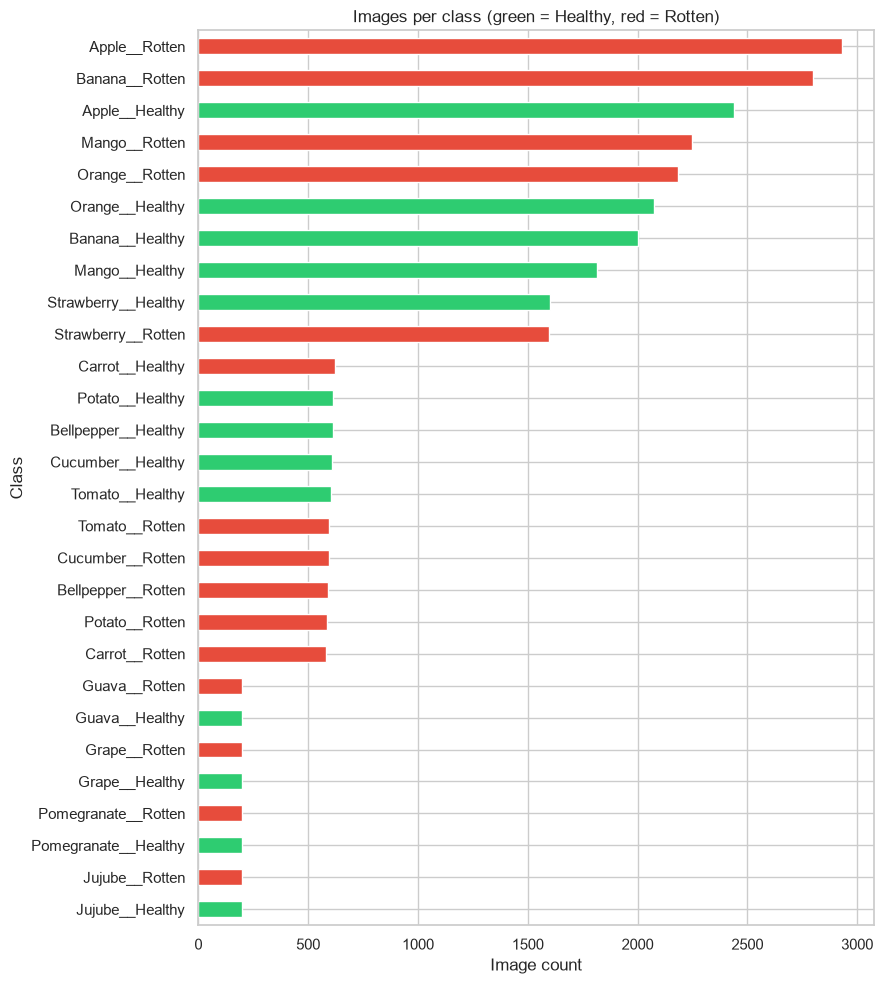

Smallest class: Jujube__Healthy (200 images)
Largest class: Apple__Rotten (2930 images)
Imbalance ratio (max/min): 14.65x


In [20]:
class_counts = df["class_name"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(9, 10))
colors = ["#e74c3c" if "rot" in c.lower() else "#2ecc71" for c in class_counts.index]
class_counts.plot(kind="barh", ax=ax, color=colors)
ax.set_xlabel("Image count")
ax.set_ylabel("Class")
ax.set_title("Images per class (green = Healthy, red = Rotten)")
plt.tight_layout()
plt.show()

print("Smallest class:", class_counts.idxmin(), f"({class_counts.min()} images)")
print("Largest class:", class_counts.idxmax(), f"({class_counts.max()} images)")
print(f"Imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}x")

## 6. Healthy vs Rotten by Category

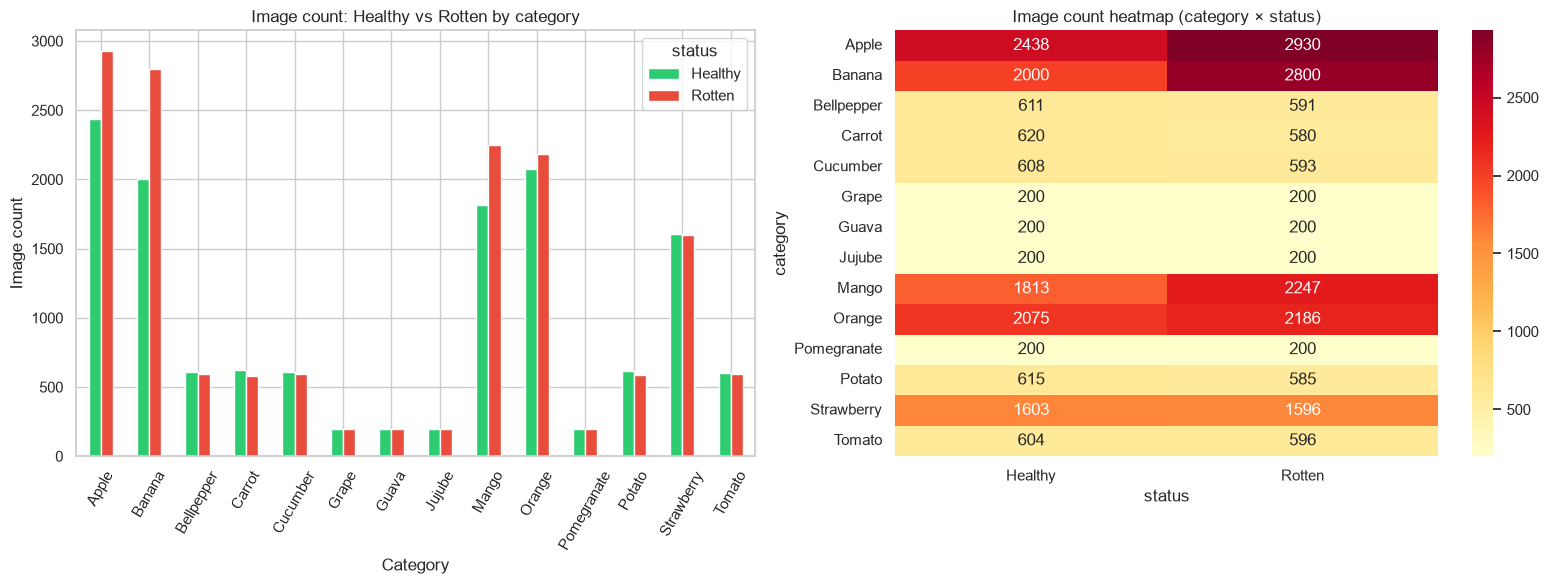

status,Healthy,Rotten,total,healthy_ratio
category,,,,
Apple,2438,2930,5368,0.45
Banana,2000,2800,4800,0.42
Orange,2075,2186,4261,0.49
Mango,1813,2247,4060,0.45
Strawberry,1603,1596,3199,0.50
Bellpepper,611,591,1202,0.51
Cucumber,608,593,1201,0.51
Carrot,620,580,1200,0.52
Tomato,604,596,1200,0.50


In [21]:
pivot = df.pivot_table(index="category", columns="status", values="filepath", aggfunc="count", fill_value=0)
pivot = pivot.reindex(columns=[c for c in ["Healthy", "Rotten", "Unknown"] if c in pivot.columns])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot.plot(kind="bar", stacked=False, ax=axes[0], color=["#2ecc71", "#e74c3c", "#95a5a6"])
axes[0].set_title("Image count: Healthy vs Rotten by category")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Image count")
axes[0].tick_params(axis="x", rotation=60)

sns.heatmap(pivot, annot=True, fmt="d", cmap="YlOrRd", ax=axes[1])
axes[1].set_title("Image count heatmap (category × status)")

plt.tight_layout()
plt.show()

pivot["total"] = pivot.sum(axis=1)
if "Healthy" in pivot.columns and "Rotten" in pivot.columns:
    pivot["healthy_ratio"] = (pivot["Healthy"] / pivot["total"]).round(2)
pivot.sort_values("total", ascending=False)

## 7. File Formats & Corrupt Image Check

Mostly `.jpg` (17,384) and `.png` (11,813), plus 80 `.jpeg` and 14 `.webp`. `PIL.Image.verify()` found 0 corrupt images out of 29,291.

In [22]:
print("File format distribution:")
print(df["extension"].value_counts())
print()

corrupt_files = []
for i, fp in enumerate(df["filepath"]):
    try:
        with Image.open(fp) as im:
            im.verify()
    except (UnidentifiedImageError, OSError) as e:
        corrupt_files.append((fp, str(e)))
    if (i + 1) % 5000 == 0:
        print(f"  ...checked {i + 1:,}/{len(df):,} images")

print(f"\nCorrupt/unreadable images: {len(corrupt_files)}")
for fp, err in corrupt_files[:20]:
    print(f"  - {fp}: {err}")

File format distribution:
extension
.jpg     17384
.png     11813
.jpeg       80
.webp       14
Name: count, dtype: int64

  ...checked 5,000/29,291 images
  ...checked 10,000/29,291 images
  ...checked 15,000/29,291 images
  ...checked 20,000/29,291 images
  ...checked 25,000/29,291 images

Corrupt/unreadable images: 0


## 8. Image Size (width × height, aspect ratio)

Median size `301×258` px, median aspect ratio ~1.00. Range `100×100` to `5616×4160`. Pipeline needs resize; prefer aspect-preserving resize + padding.

In [23]:
valid_df = df[~df["filepath"].isin([fp for fp, _ in corrupt_files])].reset_index(drop=True)
sample_df = valid_df.sample(n=min(SAMPLE_SIZE, len(valid_df)), random_state=SEED).copy()

widths, heights, modes = [], [], []
for fp in sample_df["filepath"]:
    with Image.open(fp) as im:
        w, h = im.size
        widths.append(w)
        heights.append(h)
        modes.append(im.mode)

sample_df["width"] = widths
sample_df["height"] = heights
sample_df["aspect_ratio"] = sample_df["width"] / sample_df["height"]
sample_df["color_mode"] = modes

print(f"Sample size for size/color analysis: {len(sample_df)}")
sample_df[["width", "height", "aspect_ratio"]].describe()

Sample size for size/color analysis: 1500


,width,height,aspect_ratio
count,1500.000000,1500.000000,1500.000000
mean,589.160667,531.278000,1.127041
std,808.241170,735.344903,0.251023
min,100.000000,100.000000,0.382372
25%,224.000000,224.000000,1.000000
50%,301.000000,258.000000,1.000000
75%,480.000000,402.000000,1.240310
max,5616.000000,4160.000000,2.862595


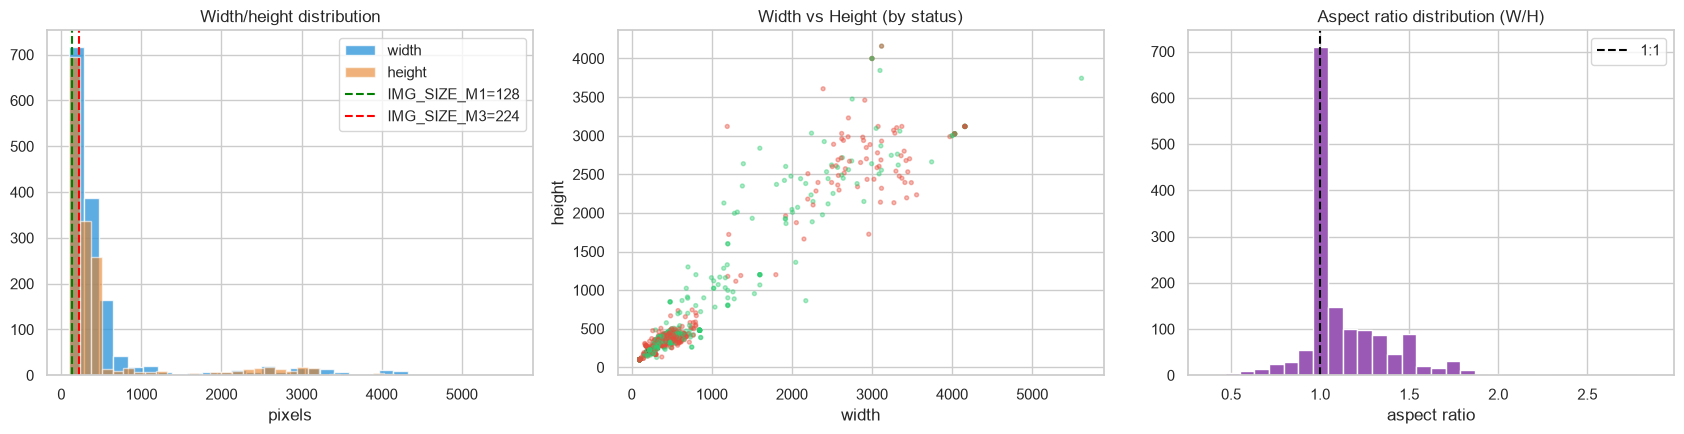

Unique (width,height) sizes in sample: 706
Color modes present: {'RGB': 1456, 'RGBA': 43, 'P': 1}


In [24]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(sample_df["width"], bins=30, color="#3498db", alpha=0.8, label="width")
axes[0].hist(sample_df["height"], bins=30, color="#e67e22", alpha=0.6, label="height")
axes[0].axvline(IMG_SIZE_M1, color="green", linestyle="--", label=f"IMG_SIZE_M1={IMG_SIZE_M1}")
axes[0].axvline(IMG_SIZE_M3, color="red", linestyle="--", label=f"IMG_SIZE_M3={IMG_SIZE_M3}")
axes[0].set_title("Width/height distribution")
axes[0].set_xlabel("pixels")
axes[0].legend()

axes[1].scatter(sample_df["width"], sample_df["height"], s=8, alpha=0.4,
                 c=sample_df["status"].map({"Healthy": "#2ecc71", "Rotten": "#e74c3c", "Unknown": "#95a5a6"}))
axes[1].set_title("Width vs Height (by status)")
axes[1].set_xlabel("width")
axes[1].set_ylabel("height")

axes[2].hist(sample_df["aspect_ratio"], bins=30, color="#9b59b6")
axes[2].axvline(1.0, color="black", linestyle="--", label="1:1")
axes[2].set_title("Aspect ratio distribution (W/H)")
axes[2].set_xlabel("aspect ratio")
axes[2].legend()

plt.tight_layout()
plt.show()

print("Unique (width,height) sizes in sample:", sample_df[["width", "height"]].drop_duplicates().shape[0])
print("Color modes present:", sample_df["color_mode"].value_counts().to_dict())

## 9. File Size Distribution

Wide range: median ~65 KB, mean ~174 KB, max ~9.5 MB. Most images are small; batch loading recommended.

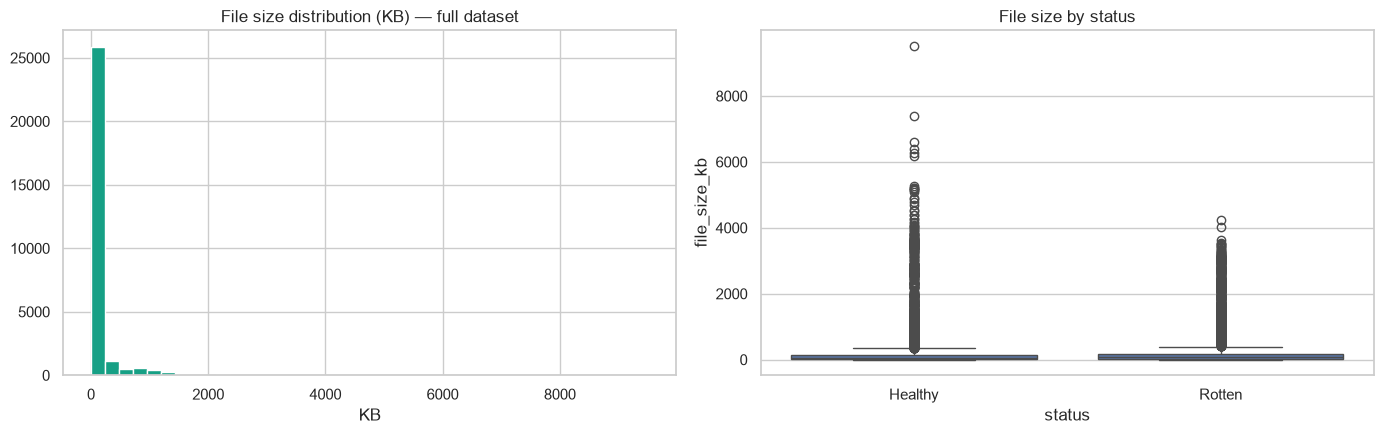

count    29291.000000
mean       173.565797
std        423.911847
min          1.051758
25%          6.792969
50%         65.044922
75%        151.560547
max       9512.117188
Name: file_size_kb, dtype: float64

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(df["file_size_kb"], bins=40, color="#16a085")
axes[0].set_title("File size distribution (KB) — full dataset")
axes[0].set_xlabel("KB")

sns.boxplot(data=df, x="status", y="file_size_kb", ax=axes[1],
            order=[s for s in ["Healthy", "Rotten", "Unknown"] if s in df["status"].unique()])
axes[1].set_title("File size by status")

plt.tight_layout()
plt.show()

df["file_size_kb"].describe()

## 10. Average Color by Status

Rotten has slightly higher RGB means and brightness than Healthy. Color alone is not a reliable signal; ColorJitter augmentation is still needed.

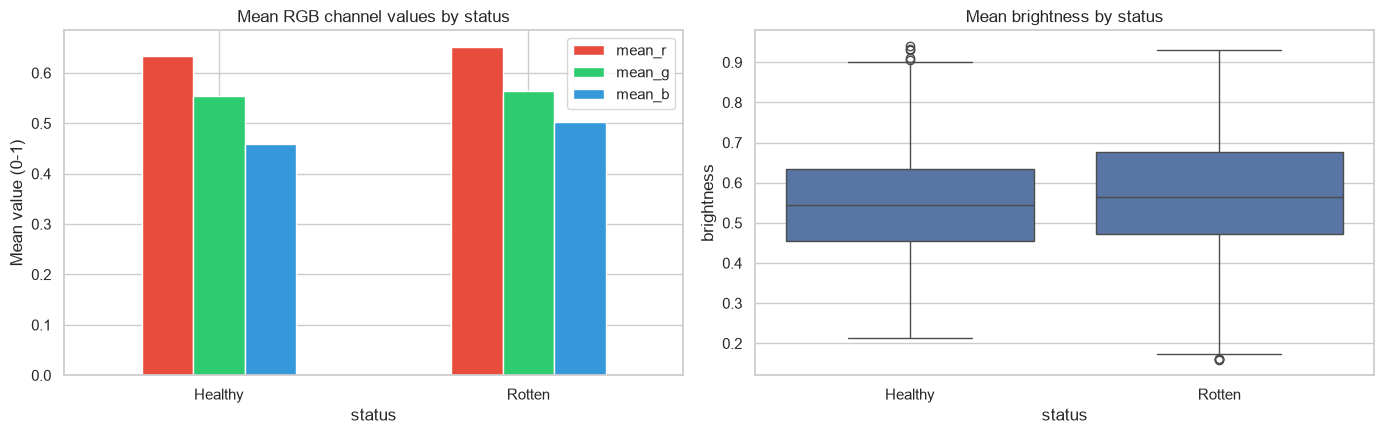

In [26]:
mean_r, mean_g, mean_b, brightness = [], [], [], []
for fp in sample_df["filepath"]:
    with Image.open(fp) as im:
        arr = np.asarray(im.convert("RGB").resize((64, 64)), dtype=np.float32) / 255.0
    mean_r.append(arr[..., 0].mean())
    mean_g.append(arr[..., 1].mean())
    mean_b.append(arr[..., 2].mean())
    brightness.append(arr.mean())

sample_df["mean_r"] = mean_r
sample_df["mean_g"] = mean_g
sample_df["mean_b"] = mean_b
sample_df["brightness"] = brightness

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sample_df.groupby("status")[["mean_r", "mean_g", "mean_b"]].mean().plot(
    kind="bar", ax=axes[0], color=["#e74c3c", "#2ecc71", "#3498db"]
)
axes[0].set_title("Mean RGB channel values by status")
axes[0].set_ylabel("Mean value (0-1)")
axes[0].tick_params(axis="x", rotation=0)

sns.boxplot(data=sample_df, x="status", y="brightness", ax=axes[1],
            order=[s for s in ["Healthy", "Rotten", "Unknown"] if s in sample_df["status"].unique()])
axes[1].set_title("Mean brightness by status")

plt.tight_layout()
plt.show()

## 11. Sample Images (Healthy vs Rotten)

Visual check of representative images across both statuses to assess quality and visual differences.

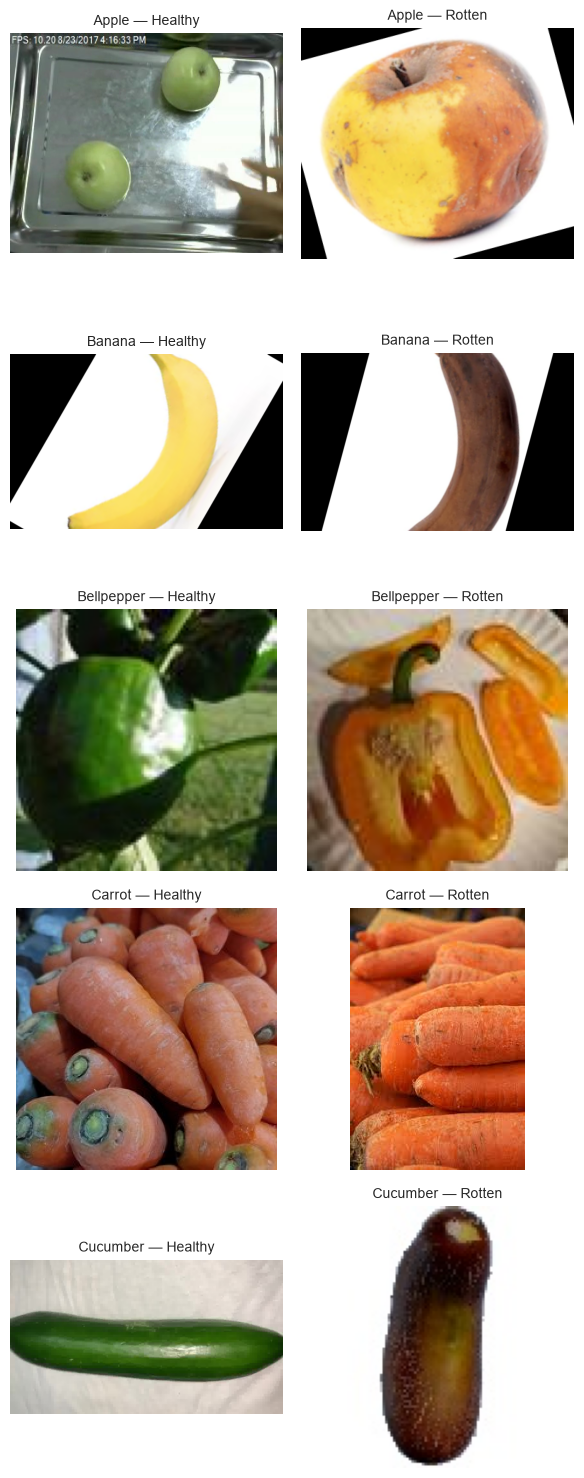

In [27]:
def plot_sample_grid(dataframe, categories, n_per_cell=1, seed=SEED):
    rng = random.Random(seed)
    statuses = ["Healthy", "Rotten"]
    fig, axes = plt.subplots(len(categories), len(statuses), figsize=(6, 3 * len(categories)))
    if len(categories) == 1:
        axes = axes.reshape(1, -1)

    for i, cat in enumerate(categories):
        for j, status in enumerate(statuses):
            subset = dataframe[(dataframe["category"] == cat) & (dataframe["status"] == status)]
            ax = axes[i, j]
            if len(subset) == 0:
                ax.axis("off")
                continue
            fp = rng.choice(subset["filepath"].tolist())
            with Image.open(fp) as im:
                ax.imshow(im.convert("RGB"))
            ax.set_title(f"{cat} — {status}", fontsize=10)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


sample_categories = sorted(df["category"].unique())[:5]
plot_sample_grid(df, sample_categories)

## 12. Save Catalog for Reuse

Catalog: 29,291 rows with image paths, class, category, status, format, and size. Saved to `data/processed/eda_catalog.csv`.

In [28]:
os.makedirs(PROCESSED_DATA_DIR, exist_ok=True)
catalog_path = os.path.join(PROCESSED_DATA_DIR, "eda_catalog.csv")
df.drop(columns=[]).to_csv(catalog_path, index=False)
print(f"Saved catalog ({len(df):,} rows) to: {catalog_path}")

Saved catalog (29,291 rows) to: d:\EP16\Deep Neural Networks\DL-ImageClassification\data\processed\eda_catalog.csv


## 13. Summary & Preprocessing Recommendations

- 28 classes, 29,291 images; no corrupt files detected.
- Strong class imbalance (14.65x); use class weights or weighted sampler.
- Variable sizes (100×100 – 5616×4160); resize to 128 (M1/M2) or 224 (M3) with padding.
- Slightly higher RGB/brightness for Rotten; augment with ColorJitter.
- Catalog saved at `data/processed/eda_catalog.csv` for split creation.